#  import kit

In [2]:
import sys
import json
from pathlib import Path
ROOT = Path().resolve().parents[1]
sys.path.append(str(ROOT / "src"))

In [3]:
import pickle
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pylatexenc
from PEC_sampler_package_cnot import cnot_PEC_Readout_Module_Sampler as pecro
from PEC_sampler_package_cnot import cnot_PEC_TQG_Module_Sampler as peccx
from PEC_sampler_package_cnot import cnot_PEC_sampler as pec
from PEC_sampler_package_cnot import cnot_Restore_Retrieve as RR
import Cnot_Fault as cxft

import qiskit as q
from qiskit import QuantumCircuit
from qiskit.visualization import *
from qiskit.circuit.library import *
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import SamplerV2
from qiskit_ibm_runtime import QiskitRuntimeService

In [ ]:
token = "EbNd_wCOqov0L2Mu4NZyOpKS_99TrgM_-tslNZenSdTR"
instance = 'crn:v1:bluemix:public:quantum-computing:us-east:a/f071734952cb4c9993a642d0a87d18bb:392306ae-fe55-475c-a8c5-978d0ba1871e::'
name = "fez"
device_name = "ibm_" + name
QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform",
        token=token,
        instance=instance,
        set_as_default=True,
        overwrite=True
    )
service = QiskitRuntimeService()
device = service.backend(device_name)
noise_model = NoiseModel.from_backend(device)

In [81]:
backend = AerSimulator.from_backend(device)
backend_options = {
    # "method": "automatic",
    "noise_model": noise_model,
    "basis_gates": noise_model.basis_gates,
    "coupling_map": device.configuration().coupling_map,
    # parallelism knobs
    # "max_parallel_experiments":32,
    # "max_parallel_threads": 0
    # "device": "GPU",  # if you have qiskit-aer-gpu
}
run_options = {
    "shots": 1024,
    # "seed_simulator": 12345,
}

sampler = SamplerV2(
    options={
        "backend_options": backend_options,
        "run_options": run_options,
        # "default_precision": 0.0,  # if you want deterministic path where applicable
    }
)
sampler.mode=backend
backendqubitNum = backend.num_qubits
print(backendqubitNum)

156


# Build Teleportation Circuit

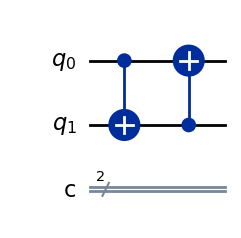

In [6]:
Cnot = QuantumCircuit(2, 2)
# Add Cnot
Cnot.cx(0, 1)
Cnot.cx(1, 0)
Cnot.draw('mpl')

# Calculate Readout PEC Observable

In [9]:
importlib.reload(pecro)
pec_readout_info = pecro.readout_pec_sampler_subsystem(Cnot, sampler, backend, shots=1024, batch_mode=True, backend_options=backend_options)

Batch mode: single process, batch circuits per measurement.
II: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
IX: [0.009765625, -0.02734375, 0.935546875, -0.00390625, -0.025390625, 0.00390625, 0.958984375, 0.005859375, -0.01171875, -0.015625, 0.94140625, -0.017578125, 0.017578125, -0.0078125, 0.955078125]
IY: [0.0, -0.009765625, 0.0625, 0.9609375, 0.052734375, -0.021484375, -0.021484375, 0.95703125, -0.005859375, -0.04296875, 0.015625, 0.953125, 0.05078125, 0.060546875, -0.005859375]
IZ: [0.94921875, -0.935546875, -0.017578125, -0.037109375, 0.947265625, -0.94921875, 0.044921875, -0.025390625, 0.951171875, -0.966796875, 0.00390625, -0.021484375, 0.931640625, -0.935546875, -0.013671875]
XI: [-0.0390625, 0.001953125, 0.015625, 0.0234375, -0.015625, -0.03125, 0.013671875, 0.0390625, 0.947265625, 0.96875, 0.96484375, 0.955078125, -0.044921875, 0.0859375, -0.0078125]
XX: [0.01953125, 0.052734375, 0.025390625, 0.009765625, -0.01171875, 0.02734375, 0.02734375, -0

In [7]:
# RR.save_readout_result(pec_readout_info, fname="Oweights", parent_dir="ROWeight")
pec_readout_info = RR.load_readout_result("ROWeight/20260413-103613/Oweights.pkl")

In [8]:
B = pec_readout_info["B"]
readout_weights = pec_readout_info["ReadoutWeight"]
print("B:", B, "\nReadoutWeight:", readout_weights)

B: [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-9.76562500e-03  9.57031250e-01  1.07421875e-02  1.95312500e-03
  -3.90625000e-03 -1.95312500e-03 -1.46484375e-02  0.00000000e+00
   1.46484375e-02 -6.83593750e-03 -1.95312500e-03  1.07421875e-02
   9.76562500e-04 -1.26953125e-02 -5.85937500e-03  1.66015625e-02]
 [ 5.37109375e-03  1.51367188e-02  9.53613281e-01  2.09960938e-02
  -2.97851562e-02  2.49023438e-02  2.39257812e-02 -2.44140625e-03
   5.02929688e-02 -7.66601562e-02 -8.74023438e-02 -2.58789062e-02
  -1.02539062e-02  5.22460938e-02  1.22070312e-02 -1.61132812e-02]
 [ 2.92968750e-03  1.07421875e-02 -3.41796875e-02  9.45312500e-01
  -1.07421875e-02  9.76562500e-04  2.05078125e-02  1.36718750e-02
  -4.88281250e-03 -2.24609375e-02  5.37109375e-02 -1.17187500e-02
   3

# Calculate CNOT PEC Weight

In [12]:
importlib.reload(peccx)
pack = peccx.compute_tqg_matrices(sampler, Cnot, shots=1024, obs_batch=1024)

num_qubits: 2
(c0,t1) 1/16 (active=[0, 1])
(c0,t1) 2/16 (active=[0, 1])
(c0,t1) 3/16 (active=[0, 1])
(c0,t1) 4/16 (active=[0, 1])
(c0,t1) 5/16 (active=[0, 1])
(c0,t1) 6/16 (active=[0, 1])
(c0,t1) 7/16 (active=[0, 1])
(c0,t1) 8/16 (active=[0, 1])
(c0,t1) 9/16 (active=[0, 1])
(c0,t1) 10/16 (active=[0, 1])
(c0,t1) 11/16 (active=[0, 1])
(c0,t1) 12/16 (active=[0, 1])
(c0,t1) 13/16 (active=[0, 1])
(c0,t1) 14/16 (active=[0, 1])
(c0,t1) 15/16 (active=[0, 1])
(c0,t1) 16/16 (active=[0, 1])
num_qubits: 2
(c1,t0) 1/16 (active=[0, 1])
(c1,t0) 2/16 (active=[0, 1])
(c1,t0) 3/16 (active=[0, 1])
(c1,t0) 4/16 (active=[0, 1])
(c1,t0) 5/16 (active=[0, 1])
(c1,t0) 6/16 (active=[0, 1])
(c1,t0) 7/16 (active=[0, 1])
(c1,t0) 8/16 (active=[0, 1])
(c1,t0) 9/16 (active=[0, 1])
(c1,t0) 10/16 (active=[0, 1])
(c1,t0) 11/16 (active=[0, 1])
(c1,t0) 12/16 (active=[0, 1])
(c1,t0) 13/16 (active=[0, 1])
(c1,t0) 14/16 (active=[0, 1])
(c1,t0) 15/16 (active=[0, 1])
(c1,t0) 16/16 (active=[0, 1])


In [13]:
pec_tqg_info = peccx.averaged_pauli_twirling_matrix(pack, B=pec_readout_info["B"])
tqg_weights = peccx.compute_inv_weights_for_package(pec_tqg_info)
tqg_weights

{(0,
  1): array([ 7.47683194e-01,  2.55898416e-01, -4.16565847e-03, -3.97549673e-03,
        -6.49745209e-03,  3.88907234e-03,  2.51606138e-01, -2.59808805e-01,
         2.64914425e-03, -2.42523342e-03, -2.56111118e-01,  2.65981037e-01,
         2.57923275e-01, -2.52261000e-01, -6.43360123e-05, -3.21177924e-04]),
 (1,
  0): array([ 7.44821293e-01, -8.22454203e-03,  1.01760523e-02,  2.57892660e-01,
         2.61162873e-01,  1.14334675e-04, -2.26486099e-03, -2.53282236e-01,
        -5.91805058e-03,  2.48468580e-01, -2.47151672e-01, -5.14045902e-03,
        -2.90389991e-03, -2.58293156e-01,  2.59421020e-01,  1.12206302e-03])}

In [14]:
RR.save_vectors(tqg_weights, fname="Gweights", parent_dir="TQGWeight")

{'dir': 'TQGWeight/20260413-103740',
 'npy': 'TQGWeight/20260413-103740/Gweights.npy',
 'npz': 'TQGWeight/20260413-103740/Gweights.npz',
 'csv_list': ['TQGWeight/20260413-103740/Gweights_c0_t1.csv',
  'TQGWeight/20260413-103740/Gweights_c1_t0.csv'],
 'meta_json': 'TQGWeight/20260413-103740/Gweights_meta.json',
 'mat': 'TQGWeight/20260413-103740/Gweights.mat'}

In [9]:
load_weights = RR.load_vectors("TQGWeight/20260413-103740/Gweights.npy")
tqg_weights = load_weights["vectors"]
tqg_weights

{(0,
  1): array([ 7.47683194e-01,  2.55898416e-01, -4.16565847e-03, -3.97549673e-03,
        -6.49745209e-03,  3.88907234e-03,  2.51606138e-01, -2.59808805e-01,
         2.64914425e-03, -2.42523342e-03, -2.56111118e-01,  2.65981037e-01,
         2.57923275e-01, -2.52261000e-01, -6.43360123e-05, -3.21177924e-04]),
 (1,
  0): array([ 7.44821293e-01, -8.22454203e-03,  1.01760523e-02,  2.57892660e-01,
         2.61162873e-01,  1.14334675e-04, -2.26486099e-03, -2.53282236e-01,
        -5.91805058e-03,  2.48468580e-01, -2.47151672e-01, -5.14045902e-03,
        -2.90389991e-03, -2.58293156e-01,  2.59421020e-01,  1.12206302e-03])}

In [10]:
importlib.reload(pec)
importlib.reload(cxft)
importlib.reload(RR)

<module 'PEC_sampler_package_cnot.cnot_Restore_Retrieve' from '/home/xiaonan/PEC/src/PEC_sampler_package_cnot/cnot_Restore_Retrieve.py'>

In [11]:
def create_cnot_circuit(n:int):
    circuits = []
    for k in range(1, n + 1):
        qc = QuantumCircuit(2, 2)
        for i in range(k):
            if i % 2 == 0:
                qc.cx(0, 1)  # 正: 0 -> 1
            else:
                qc.cx(1, 0)  # 反: 1 -> 0
        circuits.append(qc)
    return circuits

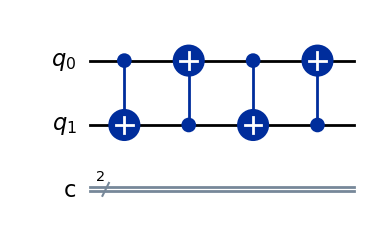

In [62]:
cnot_cir = create_cnot_circuit(4)
cnot_cir[3].draw('mpl')

In [13]:
pauli_labels = cxft.pauli_labels_k(2) 
observables = {f"meas{lbl}": cxft.obs(lbl) for lbl in pauli_labels}
def cal_expectation(res, pl_labels, readout_weights):
    m = cxft.meas_dict_to_vec(res, pl_labels)
    return cxft.expect_from_weights(readout_weights, "ZZ", m)

In [14]:
import json
import numpy as np
from pathlib import Path
from datetime import datetime

# ====== 設定輸出資料夾與檔名 ======
tag = datetime.now().strftime("%Y%m%d-%H%M%S")
out_dir = Path("outputs") / f"{tag}"
out_dir.mkdir(parents=True, exist_ok=True)

def _save_checkpoint(expectation_set: dict, json_path):
    # JSON：好讀、可追蹤
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(expectation_set, f, ensure_ascii=False, indent=2)

In [ ]:
inner_json_path = out_dir / "checkpoint.json"
outer_json_path = out_dir / "expectation_set.json"
expectation_set = {}
for i, cir in enumerate(cnot_cir):
    if i == 3:
        plan = cxft.prepare_tqg_pec_plan(qcircuit=cir, tqg_weights=tqg_weights)
        expect = []
        for j in range (60):
            res = pec.run_tqg_pec_package_sampler(
                                        sampler=sampler,
                                        qcircuit=cir,
                                        observables=observables,            # {'measXX': SparsePauliOp(...), ...}
                                        tqg_weights=tqg_weights,
                                        backend=backend,
                                        opt_level=0,
                                        shots=1024,
                                        num_workers=32,
                                        max_batch=2048,
                                        plan=plan,
                                        verbose=True)
            expect.append(cal_expectation(res, pauli_labels, readout_weights))
            # 每次新增一筆就存一次（checkpoint）
            key = f'{i+1}CNOT'
            expectation = {key: expect.copy()}
            _save_checkpoint(expectation, inner_json_path)
        expectation_set.update({f'{i+1}CNOT':expect})
        _save_checkpoint(expectation_set, outer_json_path)

Segment 1/1: full-set 0..65535 (total 65536)
[Parallel] Using 32 workers to build 65536 combinations...
[Sampler] Submitting 983040 circuits in batches of 2048...
  Progress: 2048/983040
  Progress: 12288/983040
  Progress: 22528/983040
  Progress: 32768/983040
  Progress: 43008/983040
  Progress: 53248/983040
  Progress: 63488/983040
  Progress: 73728/983040
  Progress: 83968/983040
  Progress: 94208/983040
  Progress: 104448/983040
  Progress: 114688/983040
  Progress: 124928/983040
  Progress: 135168/983040
  Progress: 145408/983040
  Progress: 155648/983040
  Progress: 165888/983040
  Progress: 176128/983040
  Progress: 186368/983040
  Progress: 196608/983040
  Progress: 206848/983040
  Progress: 217088/983040
  Progress: 227328/983040
  Progress: 237568/983040
  Progress: 247808/983040
  Progress: 258048/983040
  Progress: 268288/983040
  Progress: 278528/983040
  Progress: 288768/983040
  Progress: 299008/983040
  Progress: 309248/983040
  Progress: 319488/983040
  Progress: 3297

In [88]:
# with open("log/20260301_cx1_trial50.json", "w") as f: json.dump(expectation_set, f, indent=4)
with open("log/20260301_cx3_trial10.json", "r") as f: expectation_set = json.load(f)
expectation_set

{'results1': [1.0420847727415403,
  0.9722874308777438,
  1.0201483987260032,
  1.0280068440949193,
  1.0534323069450138,
  0.9780048177362277,
  1.0226243967131066,
  0.988812748377137,
  1.0356736248035123,
  1.0088756240495729],
 'results2': [0.9805261704111446,
  1.0301388061086036,
  0.9999176352675591,
  1.0157763322307918,
  1.0004710487452668,
  1.007323649652344,
  1.0008903229126673,
  0.999585540767051,
  0.9973188857991597,
  0.9924518480506042],
 'results3': [0.9551220817466687,
  1.030712020836866,
  1.0117693733487827,
  1.0426262303549536,
  0.9365395471168306,
  0.9395697590620222,
  1.0114340286433832,
  0.9867236239365205,
  1.0324414823943417,
  0.9114343907711099]}

In [73]:
for i,  cir in enumerate(cnot_cir):
    print(f"circuit {i}:\n", cir)

circuit 0:
           
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘
c: 2/═════
          
circuit 1:
           ┌───┐
q_0: ──■──┤ X ├
     ┌─┴─┐└─┬─┘
q_1: ┤ X ├──■──
     └───┘     
c: 2/══════════
               
circuit 2:
           ┌───┐     
q_0: ──■──┤ X ├──■──
     ┌─┴─┐└─┬─┘┌─┴─┐
q_1: ┤ X ├──■──┤ X ├
     └───┘     └───┘
c: 2/═══════════════
                    
circuit 3:
           ┌───┐     ┌───┐
q_0: ──■──┤ X ├──■──┤ X ├
     ┌─┴─┐└─┬─┘┌─┴─┐└─┬─┘
q_1: ┤ X ├──■──┤ X ├──■──
     └───┘     └───┘     
c: 2/════════════════════
                         


In [86]:
import numpy as np
from qiskit import transpile

def exp_from_counts_q0_left(counts) -> float:
    total = float(sum(counts.values()))
    if total <= 0: return 1.0
    exp = 0.0
    for bitstr, cnt in counts.items():
        p = float(cnt) / total
        ones = bitstr.replace(" ", "").count("1")
        exp += p * (-1.0 if (ones % 2 == 1) else 1.0)
    return float(exp)

n_repeat = 100
n_circuits = len(cnot_cir)

# 存所有結果：shape = (n_circuits, 100)
all_expvals = np.zeros((n_circuits, n_repeat), dtype=float)

# 存每個 circuit 的平均值
avg_expvals = []

for i, circuit in enumerate(cnot_cir):
    # 用 copy，避免直接改到原始 circuit
    circ = circuit.copy()
    circ.measure_all()
    tran = transpile(circ, backend=backend)
    batch_circuits = [tran] * n_repeat
    job = sampler.run(batch_circuits, shots=1024)
    result = job.result()
    exps = []
    for j in range(len(result)):
        counts = result[j].data.meas.get_counts()
        print(counts)
        exp_val = exp_from_counts_q0_left(counts)
        exps.append(exp_val)
    
     # 存到 n x 100 array
    all_expvals[i, :len(exps)] = exps

    # 算平均
    avg_val = float(np.mean(exps))
    avg_expvals.append(avg_val)

    print(f"circuit {i}:")
    print("100次 expectation values =")
    print(exps)
    print("average =", avg_val)
    print("-" * 50)

print("all_expvals shape =", all_expvals.shape)
print("all_expvals =")
print(all_expvals)

print("avg_expvals =")
print(avg_expvals)


{'00': 982, '01': 19, '10': 21, '11': 2}
{'10': 35, '00': 963, '11': 5, '01': 21}
{'00': 982, '01': 10, '10': 26, '11': 6}
{'00': 981, '10': 27, '01': 14, '11': 2}
{'00': 970, '10': 30, '01': 22, '11': 2}
{'00': 977, '10': 22, '11': 3, '01': 22}
{'00': 943, '01': 28, '10': 46, '11': 7}
{'00': 969, '10': 27, '01': 24, '11': 4}
{'00': 966, '01': 25, '10': 31, '11': 2}
{'00': 967, '01': 16, '10': 40, '11': 1}
{'00': 965, '01': 21, '10': 37, '11': 1}
{'00': 966, '01': 21, '10': 33, '11': 4}
{'00': 967, '11': 1, '01': 23, '10': 33}
{'00': 967, '11': 6, '10': 40, '01': 11}
{'00': 960, '10': 38, '01': 23, '11': 3}
{'00': 962, '10': 42, '01': 19, '11': 1}
{'00': 973, '01': 22, '10': 26, '11': 3}
{'00': 972, '01': 24, '10': 22, '11': 6}
{'00': 969, '01': 28, '11': 1, '10': 26}
{'00': 977, '10': 33, '01': 9, '11': 5}
{'00': 950, '01': 30, '10': 41, '11': 3}
{'00': 969, '11': 2, '10': 32, '01': 21}
{'00': 983, '01': 17, '10': 22, '11': 2}
{'00': 970, '01': 19, '10': 29, '11': 6}
{'00': 971, '01':

In [86]:
for key, value in expectation_set.items():
    print(f"{key} mean = {np.mean(value):.6f}")

results1 mean = 1.001626


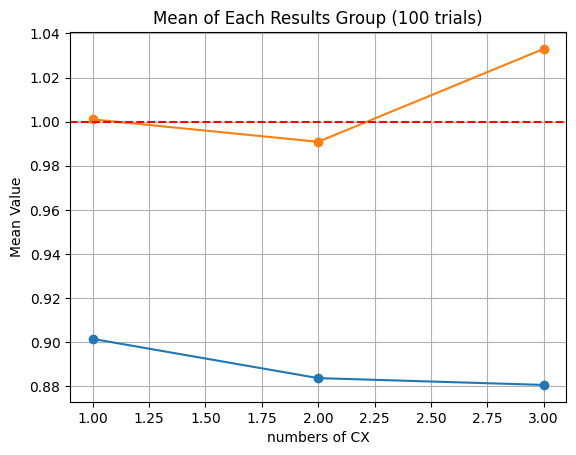

In [92]:
nopec_means = [0.901484375, 0.88369140625, 0.88060546875]
pec_means = [1.001040734, 0.990869243, 1.033000015]
labels = [1, 2, 3]
# 畫圖
plt.figure()
plt.plot(labels, nopec_means, marker='o', label='No PEC')
plt.plot(labels, pec_means, marker='o', label='PEC')
plt.axhline(1, linestyle="--", color='red', label="Ideal Value ")
plt.xlabel("numbers of CX")
plt.ylabel("Mean Value")
plt.title("Mean of Each Results Group (100 trials)")
plt.grid(True)
plt.show()

In [21]:
S_nopec = [0.93777344, 0.94566406, 0.93042969, 0.92851562, 0.95832031, 0.92886719, 0.91410156, 0.92765625, 0.90914062, 0.93417969, 
           0.93828125, 0.91984375, 0.94492188, 0.91652344, 0.92304687, 0.94628906, 0.91320312, 0.92542969, 0.94507812, 0.94976562, 
           0.92175781, 0.93871094, 0.94714844, 0.91835938, 0.94804687, 0.95492188, 0.92816406, 0.95101563, 0.91550781, 0.92519531,
           0.92539062, 0.91851562, 0.92265625, 0.93292969, 0.91589844, 0.94207031, 0.91058594, 0.93671875, 0.9253125 , 0.90550781,
           0.89703125, 0.87164063, 0.92449219, 0.93195313, 0.89085937, 0.90015625, 0.91839844,
           0.92464844, 0.91796875, 0.9409375 , 0.86324219, 0.93121094, 0.92910156, 0.93691406, 0.92703125]
# S_pec = [1.02578586, 1.01909201, 0.98948452, 0.88810680, 0.99034215, 0.94984225, 1.06196836, 1.08283221, 1.05870210]
S_pec = [1.05422710, 0.99211563, 0.95044214, 0.99567578, 0.96753688, 0.99034215, 1.06196836, 
         1.02298905, 0.95324195, 1.00860013, 0.93942985, 1.06475456, 1.01341069, 1.0030769 , 1.0293904 , 0.92538343, 1.01014463, 
         0.93166383, 1.01785468, 0.94606533, 0.96869856, 0.97917409, 0.94877809, 1.02472869, 0.99296797, 1.00050283, 
         0.95773408, 1.03938332, 1.06908888, 0.93684407, 0.92680048, 0.99342621, 0.96280653, 1.07452102, 1.03385879,
         1.01259186, 1.00382588, 0.92571563, 1.06348117, 0.94583278, 0.98091053, 1.07887884, 1.01644153, 1.02626516, 1.0169199,
         0.97770046, 0.94925662, 1.03319751, 1.01691543, 1.06295492, 1.02558424, 1.08073689, 1.04824457, 0.98787263, 0.96690591]
# [0.94972038, 1.05422710, 0.99211563, 0.95044214, 0.99567578, 1.03574354, 0.96753688, 0.99034215, 0.94984225, 1.06196836, 
# 1.02298905, 0.95324195, 1.00860013, 0.93942985, 1.06475456, 1.01341069, 1.0030769 , 1.0293904 , 0.92538343, 1.01014463, 
# 0.93166383, 1.01785468, 0.94606533, 0.94353207, 0.96869856, 0.97917409, 0.94877809, 1.02472869, 0.99296797, 1.00050283, 
# 0.96050185, 0.95773408, 1.03938332, 1.06908888, 0.93684407, 0.92680048, 0.99342621, 0.96280653, 1.07452102, 1.03385879,
# 1.01259186, 1.00382588, 0.92571563, 1.06348117, 0.94583278, 0.98091053, 1.07887884, 1.01644153, 1.02626516, 1.0169199,
# 0.97770046, 0.94925662, 1.03319751, 1.01691543, 1.06295492, 1.02558424, 1.08073689, 1.04824457, 0.98787263, 0.96690591]
n_trials = 55
summary["noPEC_mean"] = np.mean(S_nopec)
summary["PEC_mean"] = np.mean(S_pec)
summary["noPEC_std"] = np.std(S_nopec)
summary["PEC_std"] = np.std(S_pec)

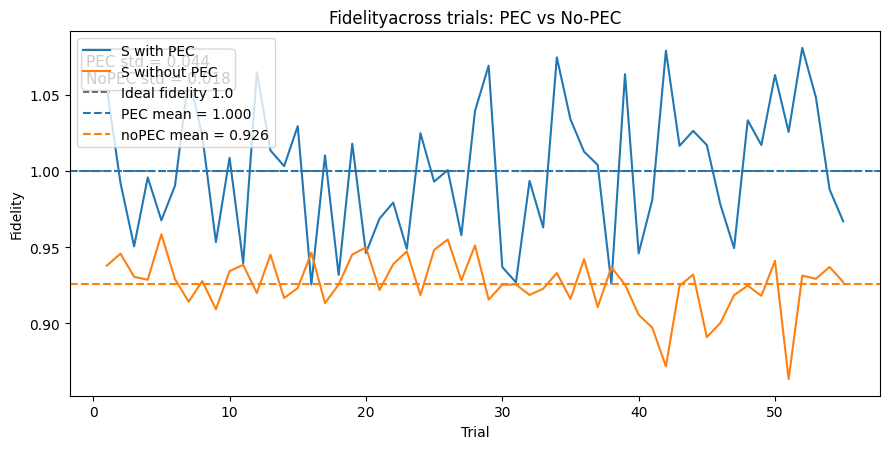

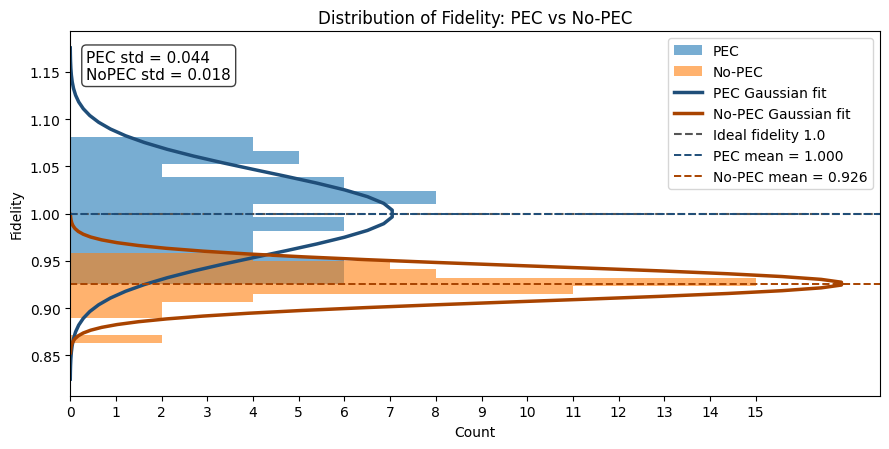

[SAVE] Fidelity_trial → output_graph/20260223-135735_55/Fidelity_trial.png
[SAVE] Fidelity_distribution → output_graph/20260223-135735_55/Fidelity_distribution.png


In [22]:
# ======  畫圖：折線 + 兩條平均線；以及分布（直方圖） ======
dark_gray = "#555555"  
pec_gauss_color = "#1f4e79"     # 深藍
nopec_gauss_color = "#a84300"   # 深橘

# ======  折線圖（每次 trial 的 S 值） ====== 
plt.figure(figsize=(9,4.6))
fig_trial = plt.gcf() 
line_pec, = plt.plot(range(1, n_trials+1), S_pec, label="S with PEC")
line_nopec, = plt.plot(range(1, n_trials+1), S_nopec, label="S without PEC")
plt.axhline(1, linestyle="--", linewidth=1.2, color=dark_gray, label="Ideal fidelity 1.0")
plt.axhline(summary["PEC_mean"], linestyle="--", color=line_pec.get_color(), label=f"PEC mean = {summary['PEC_mean']:.3f}")
plt.axhline(summary["noPEC_mean"], linestyle="--", color=line_nopec.get_color(), label=f"noPEC mean = {summary['noPEC_mean']:.3f}")
plt.xlabel("Trial")
plt.ylabel("Fidelity")
plt.title("Fidelityacross trials: PEC vs No-PEC")
textstr = (
    f"PEC std = {summary['PEC_std']:.3f}\n"
    f"NoPEC std = {summary['noPEC_std']:.3f}"
)
plt.gca().text(
    0.02, 0.85, textstr,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='bottom',
    horizontalalignment='left',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.75)
)
plt.legend()
plt.tight_layout()
plt.show()

# ======  直方圖（分布比較） ====== 
plt.figure(figsize=(9,4.6))
fig_dist = plt.gcf() 
n_pec, bins_pec, patches_pec = plt.hist(S_pec, bins=max(10, n_trials//5), alpha=0.6, label="PEC", orientation="horizontal")
n_nopec, bins_nopec, patches_nopec = plt.hist(S_nopec, bins=max(10, n_trials//5), alpha=0.6, label="No-PEC", orientation="horizontal")

# ====== 加入高斯擬合曲線 ======
# 取 bin 寬（PEC / No-PEC 用同一個 bins 效果最好）
bin_width = bins_pec[1] - bins_pec[0]
# S 軸取平滑網格
S_pec_grid = np.linspace(summary["PEC_mean"] - 4 * summary["PEC_std"], summary["PEC_mean"] + 4 * summary["PEC_std"])
S_nopec_grid = np.linspace(summary["noPEC_mean"] - 4 * summary["noPEC_std"], summary["noPEC_mean"] + 4 * summary["noPEC_std"])
def gaussian_pdf(x, mu, sigma): return (1.0 / (sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)
# PEC 高斯 → 轉成 count 尺度
x_gauss_pec = (n_trials * bin_width * gaussian_pdf(S_pec_grid, summary["PEC_mean"], summary["PEC_std"]))
# No-PEC 高斯 → 轉成 count 尺度
x_gauss_nopec = (n_trials * bin_width * gaussian_pdf(S_nopec_grid, summary["noPEC_mean"], summary["noPEC_std"]))
# 畫曲線（用 histogram 的顏色，視覺一致）
plt.plot(x_gauss_pec, S_pec_grid, color=pec_gauss_color, linewidth=2.5, label="PEC Gaussian fit")
plt.plot(x_gauss_nopec, S_nopec_grid, color=nopec_gauss_color, linewidth=2.5,  label="No-PEC Gaussian fit")

# ====== Average Line ======
plt.axhline(1, linestyle="--", color=dark_gray, label="Ideal fidelity 1.0")
plt.axhline(summary["PEC_mean"], linestyle="--", color=pec_gauss_color, linewidth=1.4, label=f"PEC mean = {summary['PEC_mean']:.3f}")
plt.axhline(summary["noPEC_mean"], linestyle="--", color=nopec_gauss_color, linewidth=1.4, label=f"No-PEC mean = {summary['noPEC_mean']:.3f}")
max_count = int(max(n_pec.max(), n_nopec.max()))
plt.xticks(range(max_count + 1))
plt.xlabel("Count")
plt.ylabel("Fidelity")
plt.title("Distribution of Fidelity: PEC vs No-PEC")
textstr = (
    f"PEC std = {summary['PEC_std']:.3f}\n"
    f"NoPEC std = {summary['noPEC_std']:.3f}"
)
plt.gca().text(
    0.02, 0.95, textstr,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.75)
)
plt.legend()
plt.tight_layout()
plt.show()
save_dir = RR.save_fidelity_figures(fig_trial, fig_dist, n_trials, parent_dir="output_graph")